<a href="https://colab.research.google.com/github/yeyevtushenko/NLP_YevtushenkoBS-25/blob/main/NLP_%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%BD%D0%B0_%D1%80%D0%BE%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%968_%D0%84%D0%B2%D1%82%D1%83%D1%88%D0%B5%D0%BD%D0%BA%D0%BE_%D0%91%D0%A1_25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Практична робота №8

##Використайте наведений приклад для реалізації архітектури трансформера, токенізатора BPE та двох методів генерації тексту жадібного (Greedy Search) і променевого пошуку (Beam Search). Натренуйте трансформер на підготовлених даних тексту.

In [1]:
from collections import Counter
import torch
import random
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import heapq
from tokenizers import Tokenizer, decoders
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
import matplotlib.pyplot as plt
import numpy as np


def save_model(model, filepath):
    """Збереження моделі в файл"""
    torch.save(model.state_dict(), filepath)
    print(f"Модель збережено в {filepath}")

def load_model(model, filepath, device="cpu"):
    state_dict = torch.load(filepath, map_location=device)
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()
    print(f"Модель завантажено з {filepath}")

In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Використовується пристрій:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Використовується пристрій: cuda
GPU: Tesla T4


Кількість тренувальних фрагментів: 552
Кількість тестових фрагментів: 237
Топ-10 найбільш частих символів:
[(' ', 23523), ('о', 12163), ('а', 10161), ('и', 7902), ('н', 7775), ('і', 7012), ('т', 6730), ('в', 6505), ('е', 5903), ('с', 5607)]
Фрагмент 1: рд поблизу й не прийняли його пропозиції дегустувати якесь там особливе саке, а одна гарненька з їхнього товариства стишене кинула в бік мізантропа: «Чи не екстреміст?» – і більше не звертала на того 
Фрагмент 2: ись, пішов уподовж салону до невідомого, – певне, на переговори.
Нам видно було, як Заболотний, за звичкою всміхаючись, щось терпляче з'ясовував із тим невідомим, намагався, певне, приспокоїти його, з
Фрагмент 3: и зосталися тільки ті, що для рейсу, проводжаючих нема, жде нас тепер поле оте аеродромне, де всюди ракетно блищать фюзеляжі, стирчать хвости, величезні крила мало не зчіплюються між собою… Причаїлись
Токенізатор BPE успішно навчено та збережено!
Оригінальний текст: Це тестовий текст для
Токени (IDs): [84, 95, 269, 320,

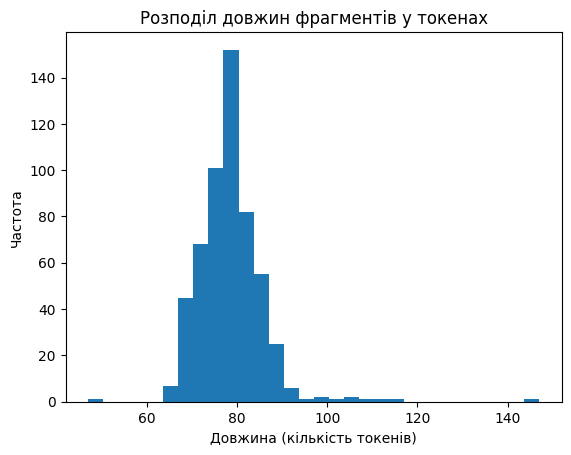

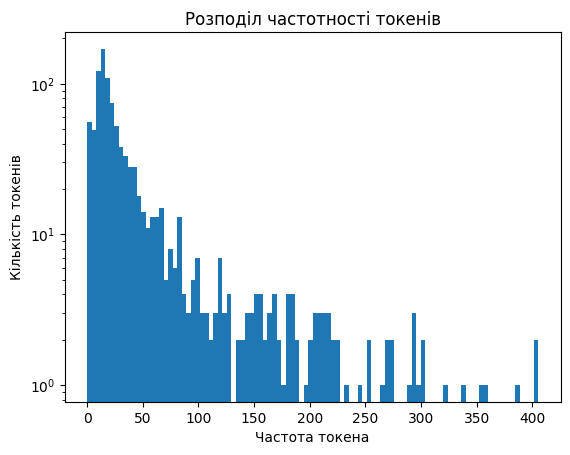

Кількість невідомих токенів у тестовій вибірці: 0
Словник токенізатора (перші 20): [(', мов', 838), ('лоп', 529), ('док', 884), ('y', 56), ('стра', 821), ('мі', 186), ('гаду', 732), (' же', 921), (', при', 559), (' тому', 893), (' ц', 203), (', під', 894), (' чи', 357), (' кі', 676), ('сили', 746), (',\xa0–', 277), ('буть', 890), ('ри', 159), ('ци', 688), ('пі', 569)]
Перші 20 токенів словника за ID: [('<pad>', 0), ('<bos>', 1), ('<eos>', 2), ('<unk>', 3), ('\n', 4), (' ', 5), ('!', 6), ('&', 7), ("'", 8), ('*', 9), (',', 10), ('.', 11), ('/', 12), ('0', 13), ('1', 14), ('2', 15), ('3', 16), ('4', 17), ('5', 18), ('6', 19)]
Seed: [883 603 244 166 444 276 230 150 503 536 834 149 102 347 181 146 463 151
 204  99 146 176 137 217 147 162 391 108 678 158 819 120 804 285 151 354
 157 426 179 565 232 501 160 192 631   5 155 105 293 593 184 369 171 546
 422 305 159 300 146 573 100 199 950 398 577 129 913 107 196 445 758 285
 414 548 689 656   0   0   0   0]
Target: [603 244 166 444 276 230 150

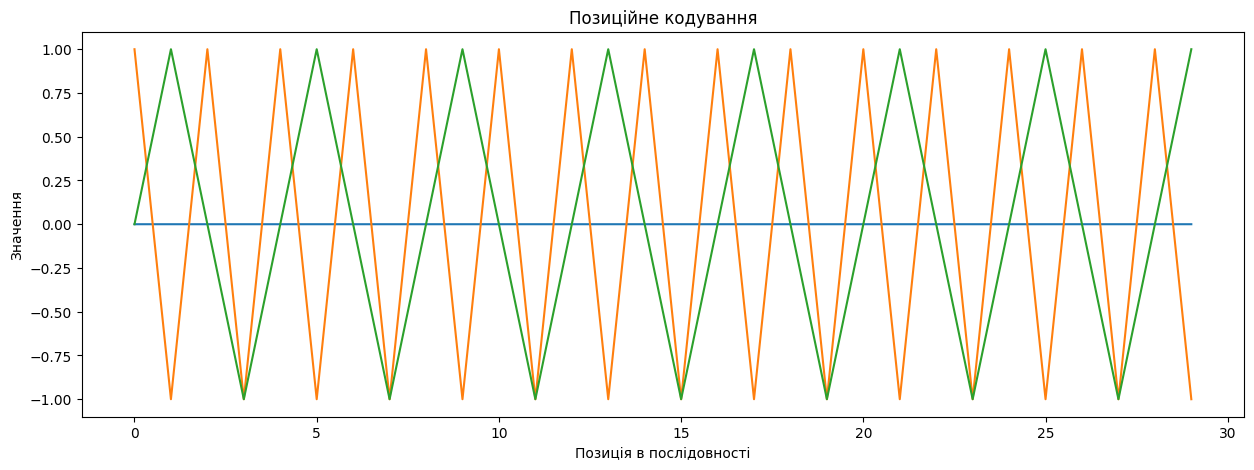

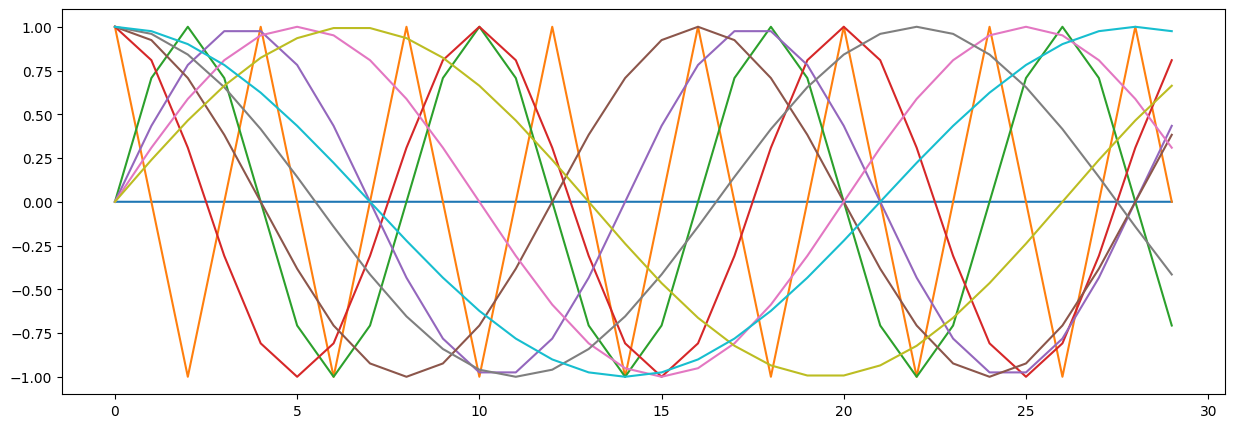

/tmp/ipykernel_4584/239706566.py:213: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.impl = nn.TransformerEncoder(*args, **kwargs)


Кількість параметрів: 2094312


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:431: UserWarning: Support for mismatched src_key_padding_mask and mask is deprecated. Use same type for both instead.
  src_key_padding_mask = F._canonical_mask(


Epoch 1/200 — Train Loss: 6.4911, Val Loss: 6.3608
Модель збережено в best_model_transTEST.pth
Epoch 2/200 — Train Loss: 6.3554, Val Loss: 6.3412
Модель збережено в best_model_transTEST.pth
Epoch 3/200 — Train Loss: 6.3448, Val Loss: 6.3307
Модель збережено в best_model_transTEST.pth
Epoch 4/200 — Train Loss: 6.3247, Val Loss: 6.3014
Модель збережено в best_model_transTEST.pth
Epoch 5/200 — Train Loss: 6.2030, Val Loss: 6.1357
Модель збережено в best_model_transTEST.pth
Epoch 6/200 — Train Loss: 5.8573, Val Loss: 5.7989
Модель збережено в best_model_transTEST.pth
Epoch 7/200 — Train Loss: 5.4122, Val Loss: 5.5115
Модель збережено в best_model_transTEST.pth
Epoch 8/200 — Train Loss: 5.0059, Val Loss: 5.3015
Модель збережено в best_model_transTEST.pth
Epoch 9/200 — Train Loss: 4.6726, Val Loss: 5.1496
Модель збережено в best_model_transTEST.pth
Epoch 10/200 — Train Loss: 4.4047, Val Loss: 5.0623
Модель збережено в best_model_transTEST.pth
Epoch 11/200 — Train Loss: 4.1443, Val Loss: 4.96

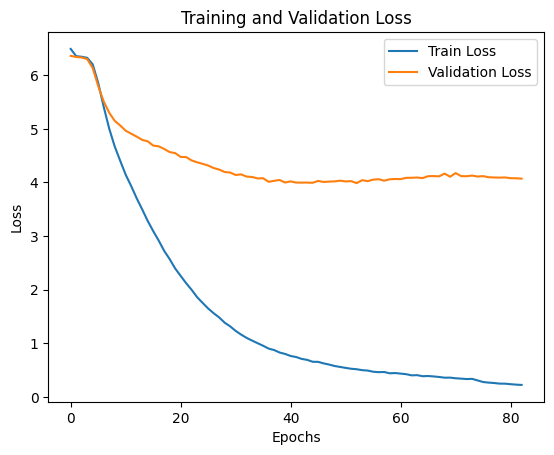

EOS Token ID: 2
Модель завантажено з best_model_transTEST.pth
Greedy result:
Соня доручила нам з Лідою контролювати тебе.
– Будь ласка, – примирливо каже Заболотний. – Тільки який з тебе контролер? К
Beam Search results:
-5.669897414845764 Заболотний вважаєліт… Біля нас не вщухає цей тонкоголосий щебет японок, і лише згодом, уже в літаку, мені в
-8.90951715590927 Заболотний вважає нічого приємнішого, як зробити на розвітання бодай маленьку послугу цьому симпатичному Заболотному‑сан, вони будуть
-9.489901770692086 Заболотний вважає нічого приємнішого, як зробити на розвітання бодай маленьку послугу цьому симпатичному Заболотному Заболотному‑сан, вони
-9.648684947387665 Заболотний вважає нічого приємнішого, як зробити на розвітання бодай маленьку послугу цьому симпатичному‑сан, вони будуть просто 
-9.901211863558274 Заболотний вважаєліт… Біля нас не вщухає цей тонкоголосий щебет японок, і лише згодом, уже в літакутий додо
-10.001240422523551 Заболотний вважаєліт… Біля нас не вщухає цей т

In [4]:
def load_chunks(fname, chunk_size=200):
    with open(fname, 'r', encoding='utf-8') as fin:
        full_text = fin.read()
    return [full_text[start:start + chunk_size] for start in range(0, len(full_text), chunk_size // 2)]

def save_chunks_to_file(chunks, output_file):
    with open(output_file, 'w', encoding='utf-8') as file:
        file.write('\n'.join(chunks))

TEXT_FILE = "20185790-2.txt"

all_chunks = load_chunks(TEXT_FILE, chunk_size=200)

TRAIN_SPLIT = int(len(all_chunks) * 0.7)
random.shuffle(all_chunks)

train_chunks = all_chunks[:TRAIN_SPLIT]
test_chunks = all_chunks[TRAIN_SPLIT:]

print(f"Кількість тренувальних фрагментів: {len(train_chunks)}")
print(f"Кількість тестових фрагментів: {len(test_chunks)}")

save_chunks_to_file(train_chunks, 'train_chunks_.txt')
save_chunks_to_file(test_chunks, 'test_chunks_.txt')

char_counts = Counter(''.join(all_chunks))
print("Топ-10 найбільш частих символів:")
print(char_counts.most_common(10))

for i in range(3):
    print(f"Фрагмент {i+1}: {random.choice(all_chunks)}")

tokenizer = Tokenizer(BPE(unk_token="<unk>"))
tokenizer.decoder = decoders.BPEDecoder()

trainer = BpeTrainer(
    vocab_size=1000,
    special_tokens=["<pad>", "<bos>", "<eos>", "<unk>"]
)

files = [TEXT_FILE]
tokenizer.train(files, trainer)

tokenizer.save("bpe_tokenizer.json")
print("Токенізатор BPE успішно навчено та збережено!")

tokenizer = Tokenizer.from_file("bpe_tokenizer.json")

test_text = "Це тестовий текст для"
encoded = tokenizer.encode(test_text)

def decode_with_spaces(tokens):
    return ''.join(
        f" {token[1:]}" if token.startswith("▁") else token
        for token in tokens.tokens
    ).strip()

decoded = decode_with_spaces(encoded)

print(f"Оригінальний текст: {test_text}")
print(f"Токени (IDs): {encoded.ids}")
print(f"Токени (фрагменти): {encoded.tokens}")
print(f"Відновлений текст: {decoded}")

print("Кількість train_chunks:", len(train_chunks))
print("Кількість test_chunks:", len(test_chunks))

train_token_ids = [tokenizer.encode(text).ids for text in train_chunks]
test_token_ids = [tokenizer.encode(text).ids for text in test_chunks]

print("Перший токенізований текст (IDs):", train_token_ids[0])
print("Перший токенізований текст (фрагменти):", tokenizer.encode(train_chunks[0]).tokens)

lengths = [len(tokens) for tokens in train_token_ids]
plt.hist(lengths, bins=30)
plt.title("Розподіл довжин фрагментів у токенах")
plt.xlabel("Довжина (кількість токенів)")
plt.ylabel("Частота")
plt.show()

token_counts = np.bincount([token for tokens in train_token_ids for token in tokens])
plt.hist(token_counts, bins=100, log=True)
plt.title("Розподіл частотності токенів")
plt.xlabel("Частота токена")
plt.ylabel("Кількість токенів")
plt.show()

unknown_tokens = sum(
    1 for tokens in test_token_ids for token in tokens
    if token == tokenizer.token_to_id("<unk>")
)
print(f"Кількість невідомих токенів у тестовій вибірці: {unknown_tokens}")

vocab = tokenizer.get_vocab()
print("Словник токенізатора (перші 20):", list(vocab.items())[:20])

sorted_vocab = sorted(vocab.items(), key=lambda x: x[1])
print("Перші 20 токенів словника за ID:", sorted_vocab[:20])

def ensure_length(sequence, length, pad_value):
    if len(sequence) < length:
        sequence = sequence + [pad_value] * (length - len(sequence))
    return sequence[:length]

class LanguageModelDataset(Dataset):
    def __init__(self, token_ids, chunk_length=100, pad_value=0):
        self.token_ids = token_ids
        self.chunk_length = chunk_length
        self.pad_value = pad_value

    def __len__(self):
        return len(self.token_ids)

    def __getitem__(self, item):
        text = self.token_ids[item]
        start_i = random.randint(0, max(0, len(text) - self.chunk_length - 1))
        chunk = text[start_i: start_i + self.chunk_length + 1]

        seed_part = chunk[:-1]
        target_part = chunk[1:]

        seed_part = ensure_length(seed_part, self.chunk_length, self.pad_value)
        target_part = ensure_length(target_part, self.chunk_length, self.pad_value)

        return np.array(seed_part), np.array(target_part)

def make_target_dependency_mask(length):
    full_mask = torch.ones(length, length)
    ignore_mask = torch.tril(full_mask) < 1
    full_mask.masked_fill_(ignore_mask, float('-inf'))
    full_mask.masked_fill_(~ignore_mask, 0)
    return full_mask

CHUNK_LENGTH = 80

train_dataset = LanguageModelDataset(train_token_ids, chunk_length=CHUNK_LENGTH)
test_dataset = LanguageModelDataset(test_token_ids, chunk_length=CHUNK_LENGTH)

seed, target = train_dataset[0]
print("Seed:", seed)
print("Target:", target)

mask = make_target_dependency_mask(CHUNK_LENGTH)
print("Маска залежностей:")
print(mask)

def make_positional_encoding(max_length, embedding_size):
    time = np.pi * torch.arange(0, max_length).float()
    freq_dividers = torch.arange(1, embedding_size // 2 + 1).float()
    inputs = time[:, None] / freq_dividers[None, :]

    result = torch.zeros(max_length, embedding_size)
    result[:, 0::2] = torch.sin(inputs)
    result[:, 1::2] = torch.cos(inputs)
    return result

sample_pos_codes = make_positional_encoding(30, 30)

plt.plot(sample_pos_codes[:, :3])
plt.gcf().set_size_inches((15, 5))
plt.title("Позиційне кодування")
plt.xlabel("Позиція в послідовності")
plt.ylabel("Значення")
plt.show()

plt.plot(sample_pos_codes[:, ::3].numpy())
plt.gcf().set_size_inches((15, 5))
plt.show()

class LanguageModel(nn.Module):
    def __init__(self, vocab_size, embedding_size, backbone, emb_dropout=0.0):
        super().__init__()
        self.embedding_size = embedding_size
        self.embeddings = nn.Embedding(vocab_size, embedding_size, padding_idx=0)
        self.emb_dropout = nn.Dropout(emb_dropout)
        self.backbone = backbone
        self.out = nn.Linear(embedding_size, vocab_size)

    def forward(self, seed_token_ids):
        batch_size, max_in_length = seed_token_ids.shape
        seed_padding_mask = seed_token_ids == 0
        dependency_mask = make_target_dependency_mask(max_in_length).to(seed_token_ids.device)

        seed_embs = self.embeddings(seed_token_ids)
        pos_codes = make_positional_encoding(max_in_length, self.embedding_size).unsqueeze(0).to(seed_embs.device)
        seed_embs = seed_embs + pos_codes
        seed_embs = self.emb_dropout(seed_embs)

        target_features = self.backbone(
            seed_embs,
            mask=dependency_mask,
            src_key_padding_mask=seed_padding_mask
        )

        logits = self.out(target_features)
        return logits

def lm_cross_entropy(pred, target):
    pred_flat = pred.view(-1, pred.shape[-1])
    target_flat = target.view(-1)
    return F.cross_entropy(pred_flat, target_flat, ignore_index=0)

def lr_scheduler(optimizer):
    return torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        patience=20,
        factor=0.5
    )

class BatchFirstTransformerEncoder(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__()
        self.impl = nn.TransformerEncoder(*args, **kwargs)
        self.initialize_weights()

    def forward(self, src, *args, **kwargs):
        src = src.transpose(0, 1).contiguous()
        result = self.impl(src, *args, **kwargs)
        result = result.transpose(0, 1).contiguous()
        return result

    def initialize_weights(self):
        for param in self.impl.parameters():
            if param.dim() > 1:
                nn.init.xavier_uniform_(param)

vocab_size = len(tokenizer.get_vocab())

torch_transf_model = LanguageModel(
    vocab_size,
    256,
    BatchFirstTransformerEncoder(
        nn.TransformerEncoderLayer(
            d_model=256,
            nhead=16,
            dim_feedforward=512,
            dropout=0.1
        ),
        num_layers=3
    ),
    emb_dropout=0.1
)

def get_params_number(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Кількість параметрів:", get_params_number(torch_transf_model))

def train_eval_loop(model, train_dataset, val_dataset, num_epochs=5, lr=0.01,
                    lr_decay=0.5, patience=2, early_stopping_patience=None,
                    batch_size=64, device="cpu",
                    max_batches_per_epoch_train=None,
                    max_batches_per_epoch_val=None,
                    optimizer_ctor=optim.Adam,
                    lr_scheduler_ctor=lr_scheduler,
                    save_path="best_model_transTEST.pth"):

    model.to(device)
    optimizer = optimizer_ctor(model.parameters(), lr=lr)
    scheduler = lr_scheduler_ctor(optimizer) if lr_scheduler_ctor is not None else None

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    train_losses = []
    val_losses = []

    best_val_loss = float('inf')
    epochs_without_improvement = 0

    for epoch in range(num_epochs):
        model.train()
        train_loss_sum = 0.0
        train_batches = 0

        for batch_i, (x, y) in enumerate(train_loader):
            if max_batches_per_epoch_train is not None and batch_i >= max_batches_per_epoch_train:
                break

            x = x.long().to(device)
            y = y.long().to(device)

            optimizer.zero_grad()
            pred = model(x)
            loss = lm_cross_entropy(pred, y)
            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item()
            train_batches += 1

        train_loss = train_loss_sum / max(train_batches, 1)
        train_losses.append(train_loss)

        model.eval()
        val_loss_sum = 0.0
        val_batches = 0

        with torch.no_grad():
            for batch_i, (x, y) in enumerate(val_loader):
                if max_batches_per_epoch_val is not None and batch_i >= max_batches_per_epoch_val:
                    break

                x = x.long().to(device)
                y = y.long().to(device)

                pred = model(x)
                loss = lm_cross_entropy(pred, y)

                val_loss_sum += loss.item()
                val_batches += 1

        val_loss = val_loss_sum / max(val_batches, 1)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1}/{num_epochs} — Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

        if scheduler is not None:
            scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_without_improvement = 0
            save_model(model, save_path)
        else:
            epochs_without_improvement += 1

        if early_stopping_patience is not None and epochs_without_improvement >= early_stopping_patience:
            print("Рання зупинка!")
            break

    return train_losses, val_losses

train_losses, val_losses = train_eval_loop(
    torch_transf_model,
    train_dataset,
    test_dataset,
    num_epochs=200,
    lr=0.001,
    batch_size=32,
    early_stopping_patience=30,
    optimizer_ctor=optim.Adam,
    lr_scheduler_ctor=lr_scheduler,
    device=DEVICE,
    save_path="best_model_transTEST.pth"
)

my_model = torch_transf_model
load_model(my_model, "best_model_transTEST.pth", device=DEVICE)

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Training and Validation Loss")
plt.show()

class GreedyGenerator:
    def __init__(self, model, tokenizer, device='cpu', eos_token_id=3):
        self.model = model
        self.tokenizer = tokenizer
        self.device = torch.device(device)
        self.model.to(self.device)
        self.eos_token_id = eos_token_id

    def __call__(self, seed_text, max_steps_n=40):
        seed_tokens = self.tokenizer.encode(seed_text).ids

        for _ in range(max_steps_n):
            in_batch = torch.tensor([seed_tokens]).to(self.device)
            best_next_token = self.model(in_batch)[0, -1].argmax().item()

            if best_next_token == self.eos_token_id:
                break

            seed_tokens.append(best_next_token)

        return self.tokenizer.decode(seed_tokens, skip_special_tokens=True)

eos_token_id = tokenizer.encode("<eos>").ids[0]
print(f"EOS Token ID: {eos_token_id}")

load_model(my_model, "best_model_transTEST.pth", device=DEVICE)

generator = GreedyGenerator(
    model=my_model,
    tokenizer=tokenizer,
    device=DEVICE,
    eos_token_id=eos_token_id
)

output_text = generator("Соня доручила", max_steps_n=40)
print("Greedy result:")
print(output_text)

class BeamGenerator:
    def __init__(self, model, tokenizer, device='cpu', eos_token_id=3):
        self.model = model
        self.tokenizer = tokenizer
        self.device = torch.device(device)
        self.model.to(self.device)
        self.eos_token_id = eos_token_id

    def __call__(self, seed_text, beamsize=5, max_steps_n=40, return_hypotheses_n=5):
        seed_tokens = self.tokenizer.encode(seed_text).ids

        partial_hypotheses = [(0.0, seed_tokens)]
        final_hypotheses = []

        for _ in range(max_steps_n):
            new_partial_hypotheses = []

            for curr_log_prob, curr_tokens in partial_hypotheses:
                in_batch = torch.tensor([curr_tokens]).to(self.device)

                next_token_logits = self.model(in_batch)[0, -1]
                next_token_log_probs = F.log_softmax(next_token_logits, dim=-1)
                topk_log_probs, topk_indices = torch.topk(next_token_log_probs, beamsize)

                for log_prob, token_idx in zip(topk_log_probs.tolist(), topk_indices.tolist()):
                    new_hyp = (curr_log_prob + log_prob, curr_tokens + [token_idx])

                    if token_idx == self.eos_token_id:
                        final_hypotheses.append(new_hyp)
                    else:
                        new_partial_hypotheses.append(new_hyp)

            partial_hypotheses = heapq.nlargest(beamsize, new_partial_hypotheses, key=lambda x: x[0])

            if len(partial_hypotheses) == 0:
                break

        final_hypotheses.extend(partial_hypotheses)
        final_hypotheses = heapq.nlargest(return_hypotheses_n, final_hypotheses, key=lambda x: x[0])

        result = []
        for score, tokens in final_hypotheses:
            text = self.tokenizer.decode(tokens, skip_special_tokens=True)
            result.append((score, text))

        return result

beam_generator = BeamGenerator(
    model=my_model,
    tokenizer=tokenizer,
    device=DEVICE,
    eos_token_id=eos_token_id
)

beam_gen_variants = beam_generator(
    'Заболотний вважає',
    beamsize=100,
    return_hypotheses_n=20
)

print("Beam Search results:")
for score, pred_txt in beam_gen_variants:
    print(score, pred_txt)

## Побудуйте графік функції втрат (train loss та validation loss) і поясніть, чи досягнуто збіжності.

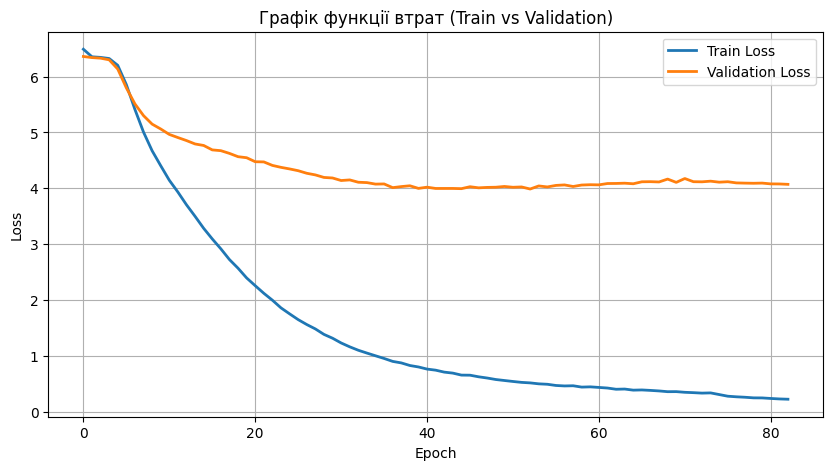

In [5]:
plt.figure(figsize=(10, 5))

plt.plot(train_losses, label="Train Loss", linewidth=2)
plt.plot(val_losses, label="Validation Loss", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Графік функції втрат (Train vs Validation)")

plt.legend()
plt.grid(True)

plt.show()

Значення train loss монотонно зменшується, що свідчить про ефективне навчання моделі на тренувальних даних. Водночас validation loss спочатку зменшується, але після певної кількості епох стабілізується та починає незначно зростати, а потім знову зменшуватись.

##Використайте модель для генерації тексту за допомогою: жадібного пошуку та променевого пошуку. Порівняйте результати обох підходів.

In [6]:
my_model = torch_transf_model
load_model(my_model, "best_model_transTEST.pth", device=DEVICE)

eos_token_id = tokenizer.token_to_id("<eos>")
print(f"EOS Token ID: {eos_token_id}")

class GreedyGenerator:
    def __init__(self, model, tokenizer, device='cpu', eos_token_id=3):
        self.model = model
        self.tokenizer = tokenizer
        self.device = torch.device(device)
        self.model.to(self.device)
        self.model.eval()
        self.eos_token_id = eos_token_id

    def __call__(self, seed_text, max_steps_n=40):
        seed_tokens = self.tokenizer.encode(seed_text).ids

        for _ in range(max_steps_n):
            in_batch = torch.tensor([seed_tokens], dtype=torch.long).to(self.device)

            with torch.no_grad():
                logits = self.model(in_batch)[0, -1]

            best_next_token = logits.argmax().item()

            if best_next_token == self.eos_token_id:
                break

            seed_tokens.append(best_next_token)

        return self.tokenizer.decode(seed_tokens, skip_special_tokens=True)


class BeamGenerator:
    def __init__(self, model, tokenizer, device='cpu', eos_token_id=3):
        self.model = model
        self.tokenizer = tokenizer
        self.device = torch.device(device)
        self.model.to(self.device)
        self.model.eval()
        self.eos_token_id = eos_token_id

    def __call__(self, seed_text, beamsize=5, max_steps_n=40, return_hypotheses_n=5):
        seed_tokens = self.tokenizer.encode(seed_text).ids

        partial_hypotheses = [(0.0, seed_tokens)]
        final_hypotheses = []

        for _ in range(max_steps_n):
            new_partial_hypotheses = []

            for curr_log_prob, curr_tokens in partial_hypotheses:
                in_batch = torch.tensor([curr_tokens], dtype=torch.long).to(self.device)

                with torch.no_grad():
                    next_token_logits = self.model(in_batch)[0, -1]

                next_token_log_probs = F.log_softmax(next_token_logits, dim=-1)
                topk_log_probs, topk_indices = torch.topk(next_token_log_probs, beamsize)

                for log_prob, token_idx in zip(topk_log_probs.tolist(), topk_indices.tolist()):
                    new_hyp = (curr_log_prob + log_prob, curr_tokens + [token_idx])

                    if token_idx == self.eos_token_id:
                        final_hypotheses.append(new_hyp)
                    else:
                        new_partial_hypotheses.append(new_hyp)

            if len(new_partial_hypotheses) == 0:
                break

            partial_hypotheses = heapq.nlargest(
                beamsize,
                new_partial_hypotheses,
                key=lambda x: x[0]
            )

        final_hypotheses.extend(partial_hypotheses)
        final_hypotheses = heapq.nlargest(
            return_hypotheses_n,
            final_hypotheses,
            key=lambda x: x[0]
        )

        result = []
        for score, tokens in final_hypotheses:
            text = self.tokenizer.decode(tokens, skip_special_tokens=True)
            result.append((score, text))

        return result

greedy_generator = GreedyGenerator(
    model=my_model,
    tokenizer=tokenizer,
    device=DEVICE,
    eos_token_id=eos_token_id
)

beam_generator = BeamGenerator(
    model=my_model,
    tokenizer=tokenizer,
    device=DEVICE,
    eos_token_id=eos_token_id
)

seed_text = "Соня доручила"

greedy_result = greedy_generator(seed_text, max_steps_n=40)
beam_results = beam_generator(
    seed_text,
    beamsize=5,
    max_steps_n=40,
    return_hypotheses_n=5
)

print("=== Greedy Search ===")
print(greedy_result)

print("\n=== Beam Search ===")
for i, (score, text) in enumerate(beam_results, 1):
    print(f"{i}. score = {score:.4f}")
    print(text)
    print()

seed_texts = [
    "Соня доручила",
    "Заболотний вважає",
    "Україна – це"
]

for seed_text in seed_texts:
    print("=" * 80)
    print(f"Початковий текст: {seed_text}")

    greedy_result = greedy_generator(seed_text, max_steps_n=40)
    beam_results = beam_generator(
        seed_text,
        beamsize=5,
        max_steps_n=40,
        return_hypotheses_n=3
    )

    print("\nGreedy Search:")
    print(greedy_result)

    print("\nBeam Search:")
    for i, (score, text) in enumerate(beam_results, 1):
        print(f"{i}. score = {score:.4f}")
        print(text)
    print()

Модель завантажено з best_model_transTEST.pth
EOS Token ID: 2
=== Greedy Search ===
Соня доручила нам з Лідою контролювати тебе.
– Будь ласка, – примирливо каже Заболотний. – Тільки який з тебе контролер? К

=== Beam Search ===
1. score = -0.5570
Соня доручила нам з Лідою контролювати тебе.
– Будь ласка, – примирливо каже Заболотний. – Тільки який з тебе контролер? К

2. score = -2.8403
Соня доручила з Лідою контролювати тебе.
– Будь ласка, – примирливо каже Заболотний. – Тільки який з тебе контролер? Ка

3. score = -4.6771
Соня доручила нам з Лідою контролювати тебе.
– Будь ласка, – примирливо каже Заболотний. – Тільки який з тебе контролер? Чи

4. score = -4.7115
Соня доручила: з Лідою контролювати тебе.
– Будь ласка, – примирливо каже Заболотний. – Тільки який з тебе контролер? К

5. score = -6.4276
Соня доручила нам з Лідою контролювати тебе.
– Будь ласка, – примирливо каже Заболотний. – Тільки який з тебе контролер? І

Початковий текст: Соня доручила

Greedy Search:
Соня доручила 

За результатами генерації видно, що для початкового фрагмента «Соня доручила» обидва методи дали майже однаковий і достатньо зв’язний текст. Жадібний пошук сформував один найімовірніший варіант, а променевий пошук, крім нього, запропонував ще кілька близьких за змістом гіпотез із незначними відмінностями у формулюваннях. Для початкових фраз «Заболотний вважає» та «Україна – це» якість генерації помітно погіршується. Текст втрачає зв’язність, з’являються штучні слова, порушення граматики та логіки. Це свідчить про те, що модель недостатньо добре узагальнює мовні закономірності для складніших або менш типових початкових запитів. Жадібний пошук у всіх випадках працює простіше: він швидко видає один варіант продовження, але може «застрягати» у локально найімовірних послідовностях. Променевий пошук розглядає кілька гіпотез одночасно, тому дає більше варіантів і потенційно кращий результат. У наведених прикладах beam search справді забезпечив більшу різноманітність, але не завжди суттєво покращив змістовність тексту.
Отже, жадібний пошук є швидшим і простішим, а променевий пошук — гнучкішим і більш варіативним. Проте якість обох методів у підсумку залежить насамперед від якості навченої моделі.

##Контрольні питання

###1. Що таке мовна модель, і які задачі вона розв'язує?
Мовна модель — це модель, яка оцінює ймовірність послідовності слів і використовується для генерації тексту, перекладу, автодоповнення та класифікації.
###2. Чому важливо враховувати ймовірність послідовності слів під час генерації тексту?
Ймовірність послідовності дозволяє вибирати найбільш правдоподібні продовження тексту, забезпечуючи його зв’язність і логічність.
###3. Які основні компоненти трансформера, і яка їхня роль у процесі моделювання мови?
Трансформер складається з embedding, позиційного кодування, механізму self-attention, feedforward мережі та вихідного шару для прогнозу токенів.
###4. Чому трансформери ефективно працюють із довгими послідовностями порівняно з RNN?
Трансформери обробляють послідовність паралельно і використовують attention, тому краще враховують довгі залежності, ніж RNN.
###5. Як працює жадібний пошук у генерації тексту? Які основні переваги та недоліки жадібного пошуку?
Жадібний пошук обирає найімовірніший токен на кожному кроці, працює швидко, але може давати менш якісний результат.
###6. У чому полягає принцип Beam Search? Як він розширює можливості генерації?
Beam Search зберігає кілька найкращих варіантів і розширює їх, що дозволяє отримати більш точний результат.
###7. Який вплив мають параметри beamsize і return_hypotheses_n на якість та різноманітність результатів?
Збільшення beamsize підвищує якість, а збільшення return_hypotheses_n підвищує різноманітність результатів.
###8. Чому для задачі моделювання мови часто використовується BPEтокенізатор?
BPE-токенізатор дозволяє ефективно працювати з текстом, розбиваючи слова на підчастини і зменшуючи словник.
###9. Як токенізатор BPE справляється з новими словами або невідомими токенами?
BPE обробляє нові слова через підслова або замінює їх на спеціальний токен <unk>.
###10. Як у функції втрат враховуються padding-токени? Чому це важливо?
Padding-токени не враховуються у функції втрат, щоб не впливати на навчання моделі.
###11. Чому трансформерам потрібне позиційне кодування?
Позиційне кодування потрібне, бо трансформер сам по собі не враховує порядок слів.
###12. Як позиційне кодування дозволяє моделі враховувати порядок слів у послідовності?
Позиційне кодування додає інформацію про позицію слова до його векторного представлення, що дозволяє моделі враховувати порядок.